# Extended dataset cleanup
Cleans `raw_scraped_extended.csv` → `cleaned_car_listings_extended.csv`

New columns vs original dataset:
- ~52 equipment boolean flags (already 0/1 from scraper)
- Basic features cleaned the same way as before
- Rows with missing basic features are dropped

In [1]:
import pandas as pd

RAW_CSV = '../data/raw_scraped_extended.csv'
CLEANED_CSV = '../data/cleaned_car_listings_extended.csv'

In [2]:
df = pd.read_csv(RAW_CSV)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (11000, 72)


,make,model,year,body_type,mileage,door_count,nr_seats,color,fuel_type,engine_capacity,...,auto_park,camera_360,rear_camera,folding_mirrors,blind_spot,lane_assist,distance_control,autonomous_driving,isofix,url
0,Renault,Scenic,2008,Compacta,87 000 km,5.0,5.0,Gri,Benzina,1 998 cm3,...,0,0,0,0,0,0,0,0,1,https://www.autovit.ro/autoturisme/anunt/renau...
1,Volkswagen,Touran,2008,Monovolum,178 400 km,5.0,NaN,Argint,Diesel,1 896 cm3,...,0,0,0,0,0,0,0,0,0,https://www.autovit.ro/autoturisme/anunt/volks...
2,Mercedes-Benz,A 180,2007,Coupe,167 500 km,5.0,NaN,Negru,Diesel,1 991 cm3,...,0,0,0,0,0,0,0,0,0,https://www.autovit.ro/autoturisme/anunt/merce...


In [3]:
print('Columns:', df.columns.tolist())

Columns: ['make', 'model', 'year', 'body_type', 'mileage', 'door_count', 'nr_seats', 'color', 'fuel_type', 'engine_capacity', 'engine_power', 'gearbox', 'transmission', 'pollution_standard', 'price', 'apple_carplay', 'android_auto', 'bluetooth', 'wireless_charging', 'navigation', 'internet', 'usb_port', 'head_up_display', 'ac', 'climatronic', 'climatronic_2zone', 'climatronic_3zone', 'climatronic_4zone', 'panoramic_roof', 'electric_sunroof', 'manual_sunroof', 'rear_glass_sunroof', 'upholstery_alcantara', 'upholstery_leather_mix', 'upholstery_leather', 'upholstery_fabric', 'electric_driver_seat', 'heated_driver_seat', 'heated_passenger_seat', 'ventilated_front_seats', 'ventilated_rear_seats', 'memory_seat', 'front_armrest', 'sport_steering_wheel', 'paddle_shifters', 'keyless_entry', 'keyless_go', 'heated_windshield', 'air_suspension', 'sport_suspension', 'predictive_acc', 'cruise_control', 'adaptive_cruise', 'bi_xenon', 'laser_lights', 'led_lights', 'xenon', 'dynamic_lights', 'follow_me

## 1. Preserve url column (pass-through to cleaned CSV)

In [4]:
# url is kept intentionally — it flows through all filtering steps and is saved to the cleaned CSV
# It is excluded from EQUIPMENT_COLS below so it doesn't affect ML features
print(f"url column present: {'url' in df.columns}")

url column present: True


## 2. Identify column groups

In [5]:
BASIC_FEATURES = [
    'make', 'model', 'year', 'body_type', 'mileage', 'door_count', 'nr_seats',
    'color', 'fuel_type', 'engine_capacity', 'engine_power',
    'gearbox', 'transmission', 'pollution_standard', 'price'
]

CATEGORICAL_COLS = [
    'make', 'model', 'body_type', 'color', 'fuel_type',
    'gearbox', 'transmission', 'pollution_standard'
]

NUMERICAL_STRING_COLS = ['mileage', 'engine_capacity', 'engine_power', 'price']
NUMERICAL_INT_COLS    = ['year', 'door_count', 'nr_seats']

# Everything after the basic features is an equipment boolean; exclude url
EQUIPMENT_COLS = [c for c in df.columns if c not in BASIC_FEATURES and c != 'url']
print(f'Equipment columns ({len(EQUIPMENT_COLS)}):', EQUIPMENT_COLS)

Equipment columns (56): ['apple_carplay', 'android_auto', 'bluetooth', 'wireless_charging', 'navigation', 'internet', 'usb_port', 'head_up_display', 'ac', 'climatronic', 'climatronic_2zone', 'climatronic_3zone', 'climatronic_4zone', 'panoramic_roof', 'electric_sunroof', 'manual_sunroof', 'rear_glass_sunroof', 'upholstery_alcantara', 'upholstery_leather_mix', 'upholstery_leather', 'upholstery_fabric', 'electric_driver_seat', 'heated_driver_seat', 'heated_passenger_seat', 'ventilated_front_seats', 'ventilated_rear_seats', 'memory_seat', 'front_armrest', 'sport_steering_wheel', 'paddle_shifters', 'keyless_entry', 'keyless_go', 'heated_windshield', 'air_suspension', 'sport_suspension', 'predictive_acc', 'cruise_control', 'adaptive_cruise', 'bi_xenon', 'laser_lights', 'led_lights', 'xenon', 'dynamic_lights', 'follow_me_home', 'front_park_sensors', 'rear_park_sensors', 'park_assist', 'auto_park', 'camera_360', 'rear_camera', 'folding_mirrors', 'blind_spot', 'lane_assist', 'distance_control',

## 3. Drop rows with missing basic features

In [6]:
before = len(df)
df = df.dropna(subset=BASIC_FEATURES)
print(f'Dropped {before - len(df)} rows with missing basic features. Remaining: {len(df)}')

Dropped 5445 rows with missing basic features. Remaining: 5555


## 4. Clean categorical columns

In [7]:
for col in CATEGORICAL_COLS:
    df[col] = df[col].astype(str).apply(lambda s: ' '.join(s.split()))
df[CATEGORICAL_COLS].head(3)

,make,model,body_type,color,fuel_type,gearbox,transmission,pollution_standard
5,Fiat,Panda,Masina de oras,Negru,Benzina,Manuala,Fata,Euro 5b
6,Seat,Leon,Compacta,Gri,Benzina,Manuala,Fata,Euro 4
8,Mercedes-Benz,GLC,SUV,Alb,Hibrid Plug-In,Automata,4x4 (automat),Euro 6


## 5. Parse numerical columns

In [8]:
# Strip units and whitespace
df['mileage']         = df['mileage'].astype(str).str.replace('km', '', regex=False)
df['engine_capacity'] = df['engine_capacity'].astype(str).str.replace('cm3', '', regex=False)
df['engine_power']    = df['engine_power'].astype(str).str.replace('CP', '', regex=False)
df['price']           = df['price'].astype(str).str.replace(',', '.', regex=False)

# Remove spaces and convert to float
for col in NUMERICAL_STRING_COLS + NUMERICAL_INT_COLS:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(' ', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where numeric conversion failed
before = len(df)
df = df.dropna(subset=NUMERICAL_STRING_COLS + NUMERICAL_INT_COLS)
print(f'Dropped {before - len(df)} rows with unparseable numeric values. Remaining: {len(df)}')

df[NUMERICAL_STRING_COLS + NUMERICAL_INT_COLS].describe()

Dropped 0 rows with unparseable numeric values. Remaining: 5555


,mileage,engine_capacity,engine_power,price,year,door_count,nr_seats
count,5555.000000,5555.000000,5555.000000,5555.000000,5555.000000,5555.000000,5555.000000
mean,147908.808101,1882.300090,181.985959,21779.292632,2018.078848,4.738794,5.029523
std,79322.086696,612.863822,94.611657,25766.543689,4.392301,0.593141,0.676681
min,1.000000,479.000000,8.000000,1000.000000,1984.000000,2.000000,1.000000
25%,88950.000000,1498.000000,120.000000,9700.000000,2015.000000,5.000000,5.000000
50%,150000.000000,1968.000000,150.000000,15500.000000,2019.000000,5.000000,5.000000
75%,201165.000000,1997.000000,204.000000,25023.500000,2021.000000,5.000000,5.000000
max,545426.000000,6749.000000,843.000000,732050.000000,2026.000000,6.000000,9.000000


## 6. Validate and fill equipment columns

In [9]:
# Equipment columns are 0/1 integers; fill any NaN with 0
df[EQUIPMENT_COLS] = df[EQUIPMENT_COLS].fillna(0).astype(int)

# Sanity check – should only contain 0 and 1
bad = {c: df[c].unique().tolist() for c in EQUIPMENT_COLS if not set(df[c].unique()).issubset({0, 1})}
if bad:
    print('WARNING – unexpected values in:', bad)
else:
    print('All equipment columns are clean binary values.')

# Equipment coverage stats
coverage = df[EQUIPMENT_COLS].mean().sort_values(ascending=False)
print('\nTop 10 most common equipment features:')
print(coverage.head(10).to_string())

All equipment columns are clean binary values.

Top 10 most common equipment features:
isofix                   0.824842
front_armrest            0.811881
rear_park_sensors        0.766877
front_park_sensors       0.619802
heated_driver_seat       0.608281
heated_passenger_seat    0.600720
android_auto             0.508911
rear_camera              0.497570
cruise_control           0.489289
follow_me_home           0.485329


## 7. Remove outliers from price

Price range kept: [2650, 122627] EUR
Dropped 110 price outliers. Remaining: 5445


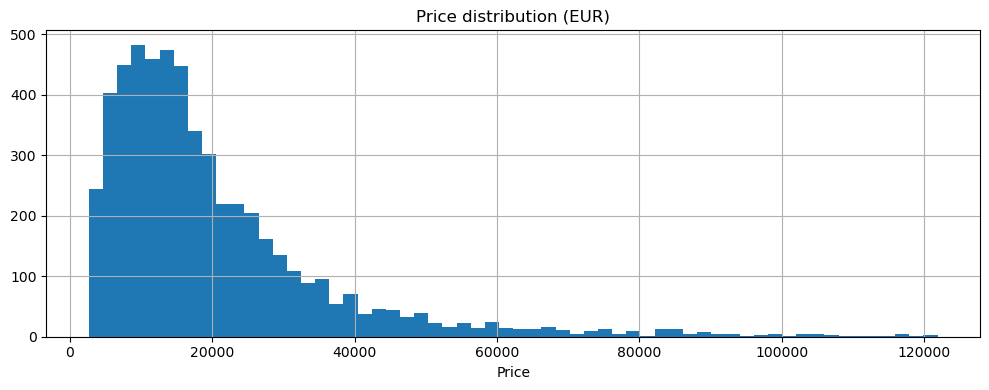

In [10]:
import matplotlib.pyplot as plt

q_low  = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
before = len(df)
df = df[(df['price'] >= q_low) & (df['price'] <= q_high)]
print(f'Price range kept: [{q_low:.0f}, {q_high:.0f}] EUR')
print(f'Dropped {before - len(df)} price outliers. Remaining: {len(df)}')

df['price'].hist(bins=60, figsize=(10, 4))
plt.title('Price distribution (EUR)')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

## 8. Duplicates check

In [11]:
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
if dups > 0:
    df = df.drop_duplicates()

Duplicate rows: 0


## 10. Final info

## 9. Feature engineering – equipment score & premium tier

In [12]:
# equipment_count: total optional features per car
# Exclude upholstery_fabric (bare/default, not a premium signal)
PREMIUM_SIGNAL_COLS = [c for c in EQUIPMENT_COLS if c != 'upholstery_fabric']
df['equipment_count'] = df[PREMIUM_SIGNAL_COLS].sum(axis=1)

# is_well_equipped: 1 if car has 5+ optional features
df['is_well_equipped'] = (df['equipment_count'] >= 7).astype(int)

# equipment_tier: categorical label
#   basic    0-4   (minimal equipment)
#   standard 5-9   (average)
#   premium  10-14 (well equipped)
#   ultra    15+   (fully loaded)
def equipment_tier(count):
    if count < 5:  return 'basic'
    if count < 10: return 'standard'
    if count < 15: return 'premium'
    return 'ultra'

df['equipment_tier'] = df['equipment_count'].apply(equipment_tier)

print('Equipment count distribution:')
print(df['equipment_count'].describe())
print()
print('Tier distribution:')
print(df['equipment_tier'].value_counts())
print()
print(f"Well-equipped (>=7 options): {df['is_well_equipped'].sum()} / {len(df)}")

Equipment count distribution:
count    5445.000000
mean        9.955005
std         4.723703
min         0.000000
25%         7.000000
50%        10.000000
75%        14.000000
max        20.000000
Name: equipment_count, dtype: float64

Tier distribution:
equipment_tier
premium     2068
standard    1577
ultra        978
basic        822
Name: count, dtype: int64

Well-equipped (>=7 options): 4088 / 5445


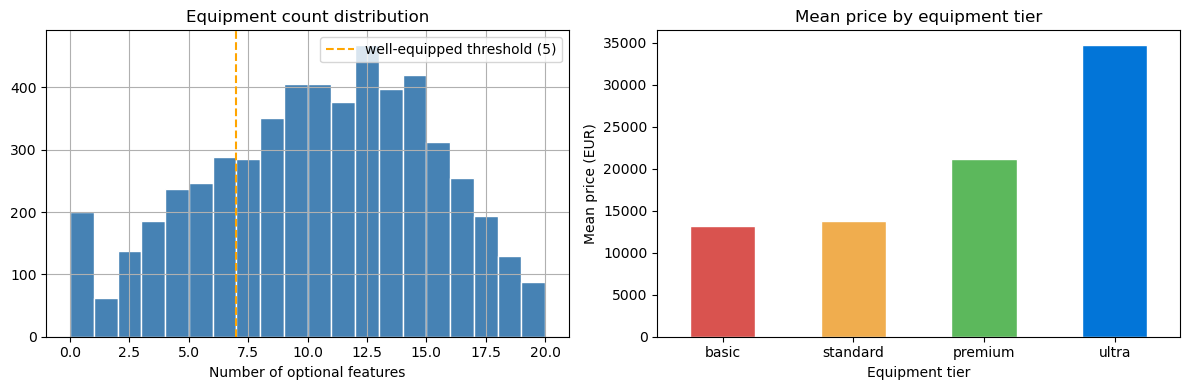

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Equipment count histogram
df['equipment_count'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(7, color='orange', linestyle='--', label='well-equipped threshold (5)')
axes[0].set_title('Equipment count distribution')
axes[0].set_xlabel('Number of optional features')
axes[0].legend()

# Mean price per tier
tier_order = ['basic', 'standard', 'premium', 'ultra']
tier_price = df.groupby('equipment_tier')['price'].mean().reindex(tier_order)
tier_price.plot(kind='bar', ax=axes[1], color=['#d9534f', '#f0ad4e', '#5cb85c', '#0275d8'], edgecolor='white')
axes[1].set_title('Mean price by equipment tier')
axes[1].set_xlabel('Equipment tier')
axes[1].set_ylabel('Mean price (EUR)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [14]:
print(f'Final dataset shape: {df.shape}')
df.info()
df.head(3)

Final dataset shape: (5445, 75)
<class 'pandas.core.frame.DataFrame'>
Index: 5445 entries, 5 to 10996
Data columns (total 75 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   make                    5445 non-null   object 
 1   model                   5445 non-null   object 
 2   year                    5445 non-null   int64  
 3   body_type               5445 non-null   object 
 4   mileage                 5445 non-null   int64  
 5   door_count              5445 non-null   float64
 6   nr_seats                5445 non-null   float64
 7   color                   5445 non-null   object 
 8   fuel_type               5445 non-null   object 
 9   engine_capacity         5445 non-null   int64  
 10  engine_power            5445 non-null   int64  
 11  gearbox                 5445 non-null   object 
 12  transmission            5445 non-null   object 
 13  pollution_standard      5445 non-null   object 
 14  price       

,make,model,year,body_type,mileage,door_count,nr_seats,color,fuel_type,engine_capacity,...,folding_mirrors,blind_spot,lane_assist,distance_control,autonomous_driving,isofix,url,equipment_count,is_well_equipped,equipment_tier
5,Fiat,Panda,2013,Masina de oras,154765,5.0,5.0,Negru,Benzina,875,...,0,0,0,0,0,1,https://www.autovit.ro/autoturisme/anunt/fiat-...,3,0,basic
6,Seat,Leon,2008,Compacta,164500,5.0,5.0,Gri,Benzina,1984,...,0,0,0,0,0,1,https://www.autovit.ro/autoturisme/anunt/seat-...,7,1,standard
8,Mercedes-Benz,GLC,2020,SUV,163000,5.0,5.0,Alb,Hibrid Plug-In,1991,...,0,0,0,0,0,1,https://www.autovit.ro/autoturisme/anunt/merce...,14,1,premium


## 11. Save

In [15]:
df.to_csv(CLEANED_CSV, index=False)
print(f'Saved {len(df)} rows × {len(df.columns)} columns → {CLEANED_CSV}')
print('New feature columns: equipment_count, is_well_equipped, equipment_tier')
df[['equipment_count', 'is_well_equipped', 'equipment_tier', 'price']].head(10)

Saved 5445 rows × 75 columns → ../data/cleaned_car_listings_extended.csv
New feature columns: equipment_count, is_well_equipped, equipment_tier


,equipment_count,is_well_equipped,equipment_tier,price
5,3,0,basic,3990.0
6,7,1,standard,6400.0
8,14,1,premium,30371.0
9,9,1,standard,2800.0
10,15,1,ultra,18950.0
15,2,0,basic,6900.0
19,1,0,basic,3000.0
22,9,1,standard,27990.0
24,14,1,premium,22990.0
30,6,0,standard,11990.0
